In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("house_price_regression_dataset.csv")

In [3]:
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [4]:
df.isnull().sum()

Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

In [5]:
df.shape

(1000, 8)

In [1]:
from sklearn.model_selection import train_test_split


In [11]:
y = df["House_Price"]
x = df[["Square_Footage","Num_Bedrooms","Num_Bathrooms","Year_Built","Lot_Size","Garage_Size","Neighborhood_Quality"]]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [14]:
from   sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
predictions = model.predict(x_test)
predictions

array([ 868687.10747903,  490337.89825447,  945667.12422537,
       1033402.87599247,  776698.77390587,  732444.09335308,
        995051.99156272,  885174.76924362,  796730.53817137,
        931741.09209272,  759486.73376772,  645409.40410205,
        217706.20688729, 1047436.52669427,  536985.283711  ,
        187868.55343105,  456819.02346557,  357933.98497768,
        743138.35721931,  362670.94796792,  775101.05248527,
        478174.42921702,  680966.06345079,  889457.56001471,
        447158.93387226,  396997.78641332,  454334.22026962,
        442837.53540887,  187336.81096629,  491668.18070411,
        279715.81740979,  895941.0005743 ,  783583.19778842,
        352212.91737968,  479313.284656  ,  766612.6601435 ,
        474636.25109508,  572446.37288032,  303449.70619643,
        154599.27036073,  304341.05092125,  299677.00775284,
        508575.91105888,  309977.51725285, 1082131.76994762,
       1011343.63575232,  760359.56460958,  807425.57445877,
       1025548.17009414,

In [23]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, predictions)
print(r2)

0.9984263636823408


In [21]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
mse = mean_squared_error(y_test, predictions)
print("MSE ",mse)

mae =  mean_absolute_error(y_test, predictions)
print("MAE ",mae)

MSE  101434798.50566845
MAE  8174.583600008741


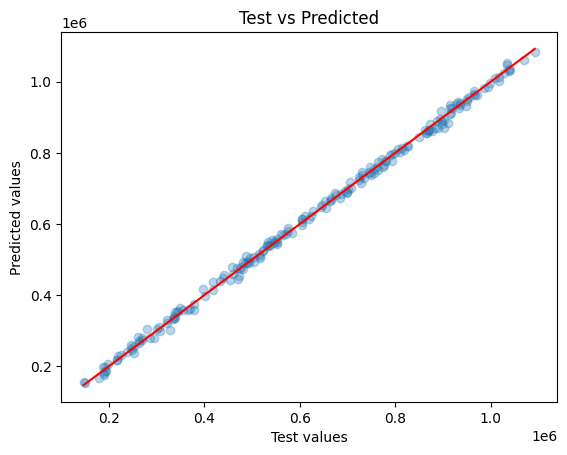

In [22]:
plt.figure()
plt.scatter(y_test, predictions, alpha=0.3)

min_val = min(y_test.min(), predictions.min())
max_val = max(y_test.max(), predictions.max())

plt.plot([min_val, max_val], [min_val, max_val],color='red')
plt.xlabel("Test values")
plt.ylabel("Predicted values")
plt.title("Test vs Predicted")
plt.show()